# Manipulação de dados

<div class="alert alert-info">
    <b>Informações:</b>
    <details>
        <summary>
            <font>
                <b>São clicaveis</b>
            </font>
        </summary>
  
<ul>
        <li>
            <b>Guardam conteúdo</b>
        </li>
    </ul>
</details>
</div>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

questionario = pd.read_excel('dados3.xls')
questionario

,Turma,Sexo,Idade,Alt,Peso,Filhos,Fuma,Toler,Exerc,Cine,OpCine,TV,OpTV
0,A,F,17,1.60,60.5,2,NAO,P,0,1,B,16,R
1,A,F,18,1.69,55.0,1,NAO,M,0,1,B,7,R
2,A,M,18,1.85,72.8,2,NAO,P,5,2,M,15,R
3,A,M,25,1.85,80.9,2,NAO,P,5,2,B,20,R
4,A,F,19,1.58,55.0,1,NAO,M,2,2,B,5,R
5,A,M,19,1.76,60.0,3,NAO,M,2,1,B,2,R
6,A,F,20,1.60,58.0,1,NAO,P,3,1,B,7,R
7,A,F,18,1.64,47.0,1,SIM,I,2,2,M,10,R
8,A,F,18,1.62,57.8,3,NAO,M,3,3,M,12,R
9,A,F,17,1.64,58.0,2,NAO,M,2,2,M,10,R


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Classificação de variáveis</b>
        </font>
    </summary>

<table style="color: #ffffff">
    <tr>
        <td><b>Variável</b></td>
        <td><b>Tipo</b></td>
    </tr>
    <tr>
        <td>Turma</td>
        <td>Qualitativa Nominal</td>
    </tr>
    <tr>
        <td>Sexo</td>
        <td>Qualitativa Nominal</td>
    </tr>
    <tr>
        <td>Idade</td>
        <td>Quantitativa discreta</td>
    </tr>
    <tr>
        <td>Alt</td>
        <td>Quantitativa contínua</td>
    </tr>
    <tr>
        <td>Peso</td>
        <td>Quantitativa contínua</td>
    </tr>
    <tr>
        <td>Filhos</td>
        <td>Quantitativa discreta</td>
    </tr>
      <tr>
        <td>Fuma</td>
        <td>Qualitativa Nominal</td>
    </tr>
      <tr>
        <td>Toler</td>
        <td>Qualitativa Ordinal</td>
    </tr>
    <tr>
        <td>Exerc</td>
        <td>Quantitativa discreta</td>
    </tr>
     <tr>
        <td>Cine</td>
        <td>Quantitativa discreta</td>
    </tr>
    <tr>
        <td>OpCine</td>
        <td>Qualitativa Ordinal</td>
    </tr>
    <tr>
        <td>TV</td>
        <td>Quantitativa discreta</td>
    </tr>
    <tr>
        <td>OpTV</td>
        <td>Qualitativa Ordinal</td>
    </tr>

</table>
</details>

In [30]:
lista_de_colunas = []
dict_frequencias = {}
gap_alt = [1.40,1.50,1.60,1.70,1.80,1.90]
gap_peso = [40,50,60,70,80,90,100]

for coluna in questionario.columns:
    if(coluna.lower() == 'alt'):
        df_temp = pd.cut(questionario[coluna],bins=gap_alt).value_counts().reset_index()
    elif(coluna.lower() == 'peso'):
        df_temp = pd.cut(questionario[coluna],bins=gap_peso).value_counts().reset_index()
    else:
        df_temp = questionario[coluna].value_counts().reset_index()
    df_temp.columns = [coluna, 'Frequencia']

    lista_de_colunas.append(f"freq_{coluna.lower()}")
    dict_frequencias[f"freq_{coluna.lower()}"] = df_temp

dict_frequencias

{'freq_turma':   Turma  Frequencia
 0     A          26
 1     B          24,
 'freq_sexo':   Sexo  Frequencia
 0    F          37
 1    M          13,
 'freq_idade':    Idade  Frequencia
 0     18          22
 1     17           9
 2     19           7
 3     20           4
 4     21           3
 5     25           2
 6     23           2
 7     24           1,
 'freq_alt':           Alt  Frequencia
 0  (1.6, 1.7]          23
 1  (1.5, 1.6]          12
 2  (1.7, 1.8]           9
 3  (1.8, 1.9]           5
 4  (1.4, 1.5]           1,
 'freq_peso':         Peso  Frequencia
 0   (50, 60]          23
 1   (40, 50]          10
 2   (60, 70]           6
 3   (70, 80]           5
 4   (80, 90]           5
 5  (90, 100]           1,
 'freq_filhos':    Filhos  Frequencia
 0       1          28
 1       2          14
 2       3           6
 3       4           1
 4       7           1,
 'freq_fuma':   Fuma  Frequencia
 0  NAO          44
 1  SIM           6,
 'freq_toler':   Toler  Frequencia
 

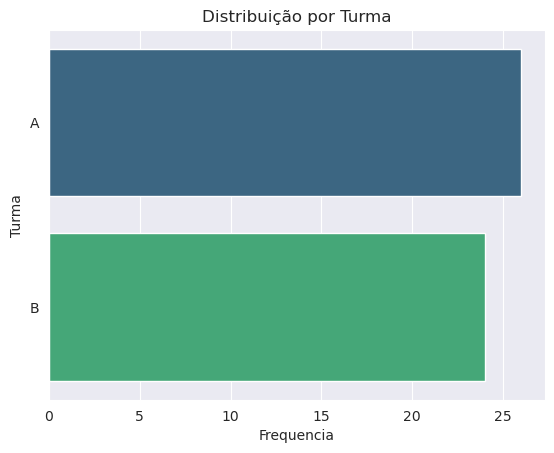

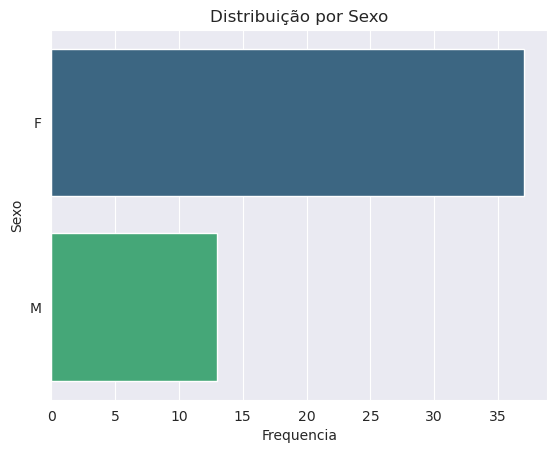

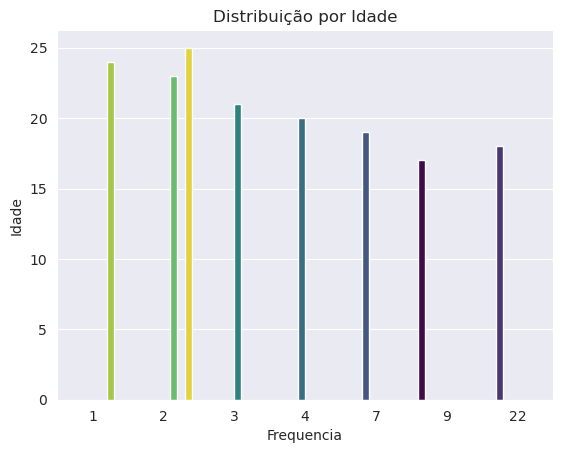

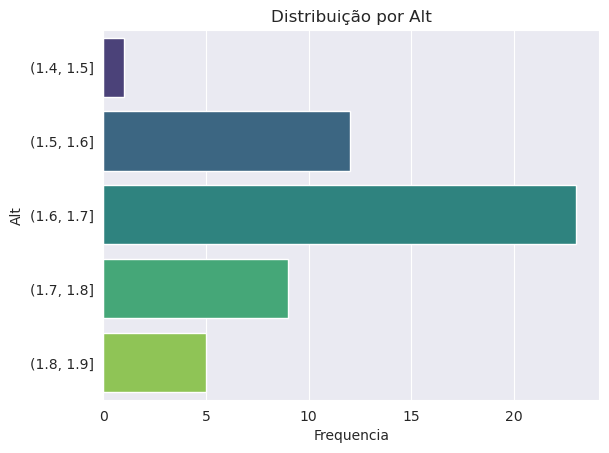

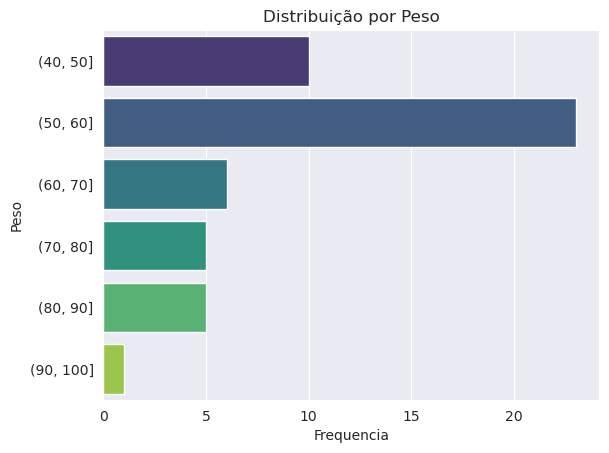

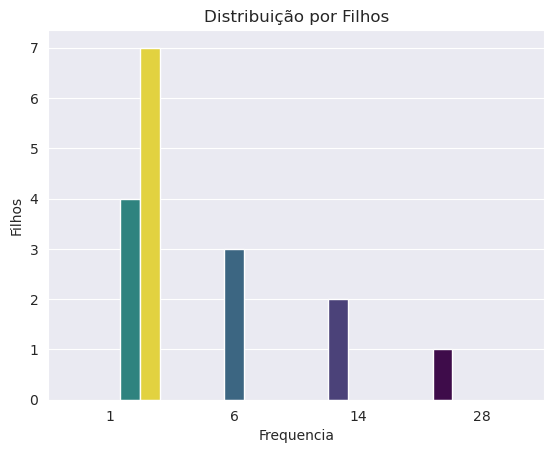

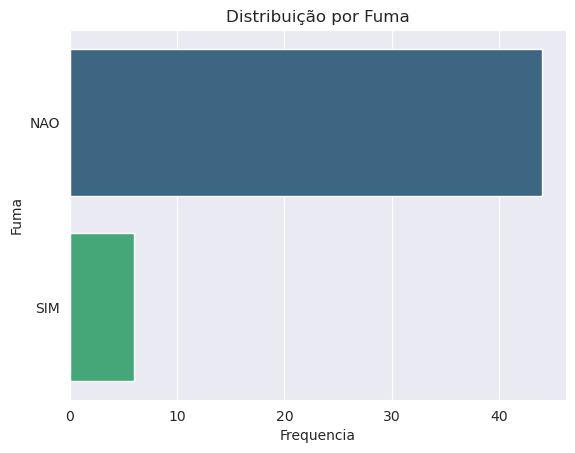

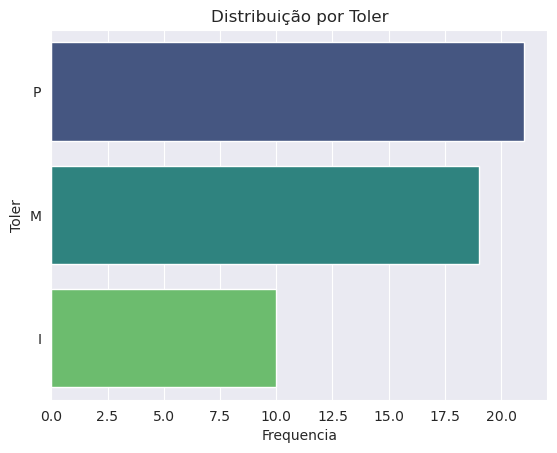

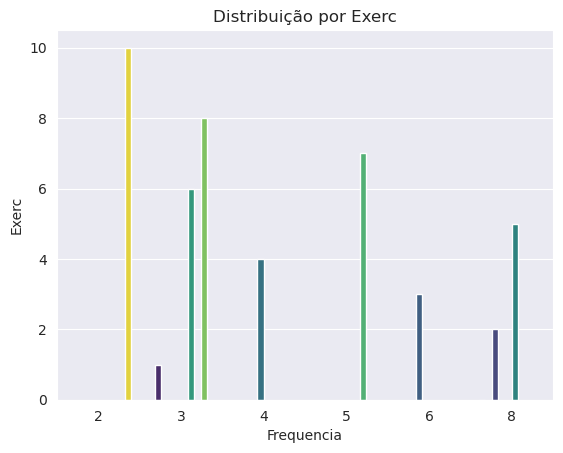

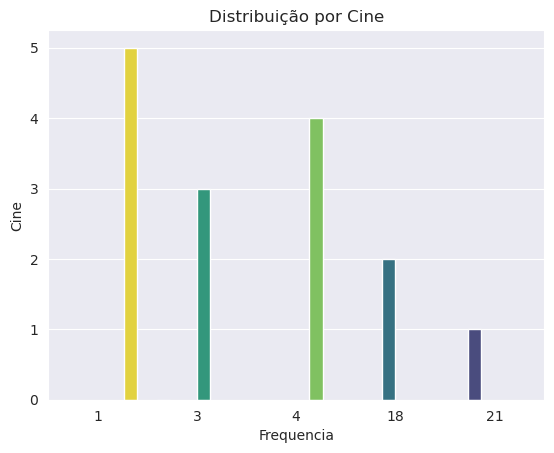

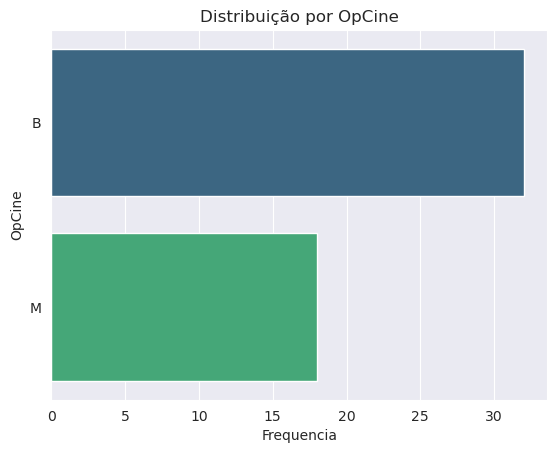

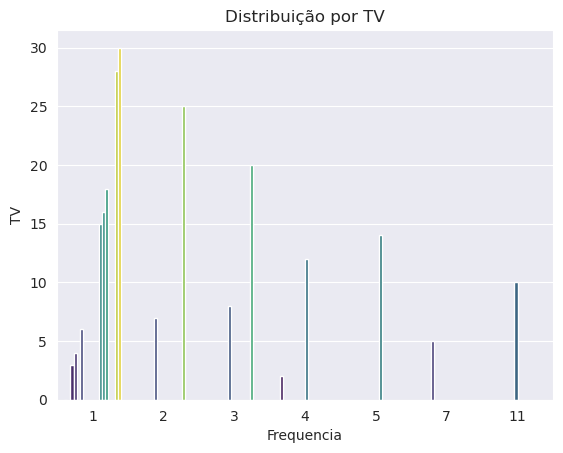

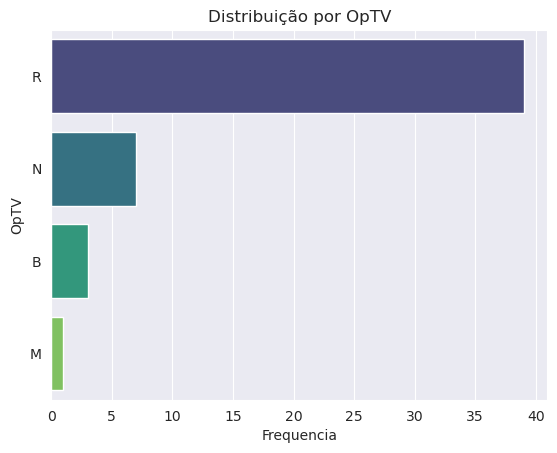

In [31]:
for nome_var in lista_de_colunas:
    df_atual = dict_frequencias[nome_var]
    coluna_cat = df_atual.columns[0] 
    
    sns.barplot(data=df_atual, x='Frequencia', y=coluna_cat, palette='viridis',hue=coluna_cat,legend=False)
    plt.title(f'Distribuição por {coluna_cat}')
    plt.show()